In [7]:
import os
import json
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [8]:
BASE_DIR = Path("/home/nathan/Documents/Projects/IA/Projeto_IA_Tumor")

DATASET_DIR = BASE_DIR / "data/dataset"
JSON_PATH = BASE_DIR / "data/DATA.json"

OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
CONFUSION_DIR = OUTPUT_DIR / "confusion_matrix"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

RANDOM_SEED = 42

In [9]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("GPU detectada:", torch.cuda.get_device_name(0))

    if torch.version.hip:
        print("ROCm detectado:", torch.version.hip)
else:
    DEVICE = torch.device("cpu")
    print("Usando CPU")

GPU detectada: AMD Radeon RX 9070 XT
ROCm detectado: 7.2.53211


In [10]:
class TumorDataset(Dataset):
    def __init__(self, samples, class_to_idx, use_crop=True):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.use_crop = use_crop

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        with open(JSON_PATH, "r") as f:
            self.metadata = json.load(f)

    def crop_region(self, image, x, y, crop_size=128):
        h, w = image.shape[:2]

        x1 = max(0, x - crop_size // 2)
        y1 = max(0, y - crop_size // 2)
        x2 = min(w, x + crop_size // 2)
        y2 = min(h, y + crop_size // 2)

        return image[y1:y2, x1:x2]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        relative_path = str(image_path).split("dataset/")[-1]
        #relative_path = relative_path.replace("/", "\\")

        if self.use_crop and relative_path in self.metadata:
            point = self.metadata[relative_path]["point"]
            image = self.crop_region(image, point["x"], point["y"])

        image = Image.fromarray(image)
        image = self.transform(image)

        label = self.class_to_idx[class_name]

        return image, label

In [11]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

all_samples = []
classes = []

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        class_name = class_dir.name
        classes.append(class_name)

        for image_path in class_dir.glob("*.jpg"):
            all_samples.append((image_path, class_name))

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_samples, temp_samples = train_test_split(
    all_samples,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in all_samples]
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=[x[1] for x in temp_samples]
)

train_dataset = TumorDataset(train_samples, class_to_idx)
val_dataset = TumorDataset(val_samples, class_to_idx)
test_dataset = TumorDataset(test_samples, class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Classes:", classes)
print("Total de imagens:", len(all_samples))

Classes: ['Astrocytoma T2', 'Ependymoma T2', 'Glioma T2', 'Hemangiopericytoma T2', 'Meningioma T2', 'Neurocytoma T2', 'Normal T2', 'Oligodendroglioma T2', 'Other T2', 'Schwannoma T2']
Total de imagens: 2976


In [13]:
model = BrainTumorCNN(num_classes=len(classes)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
val_accuracies = []

best_accuracy = 0

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_description(
            f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()

    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    accuracy = accuracy_score(all_labels, all_preds)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Accuracy={accuracy:.4f}"
    )

    if accuracy > best_accuracy:
        best_accuracy = accuracy

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_to_idx": class_to_idx,
            "accuracy": accuracy,
        }, MODEL_DIR / "best_model.pth")

Epoch 1/50 - Loss: 2.3478: 100%|██████████| 131/131 [00:10<00:00, 12.41it/s]


Epoch 1: Train Loss=2.3161 | Val Loss=1.7846 | Accuracy=0.4013


Epoch 2/50 - Loss: 1.0701: 100%|██████████| 131/131 [00:08<00:00, 15.44it/s]


Epoch 2: Train Loss=1.8440 | Val Loss=1.6355 | Accuracy=0.3991


Epoch 3/50 - Loss: 1.6862: 100%|██████████| 131/131 [00:08<00:00, 15.37it/s]


...

Epoch 48: Train Loss=0.1435 | Val Loss=0.4346 | Accuracy=0.9081


Epoch 49/50 - Loss: 0.1107: 100%|██████████| 131/131 [00:08<00:00, 15.52it/s]


Epoch 49: Train Loss=0.1779 | Val Loss=0.4693 | Accuracy=0.9170


Epoch 50/50 - Loss: 0.0110: 100%|██████████| 131/131 [00:08<00:00, 15.49it/s]


Epoch 50: Train Loss=0.1496 | Val Loss=0.4443 | Accuracy=0.9238


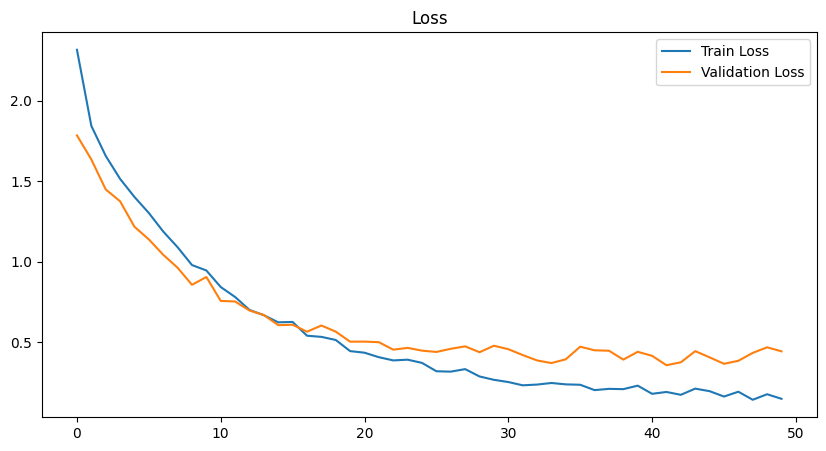

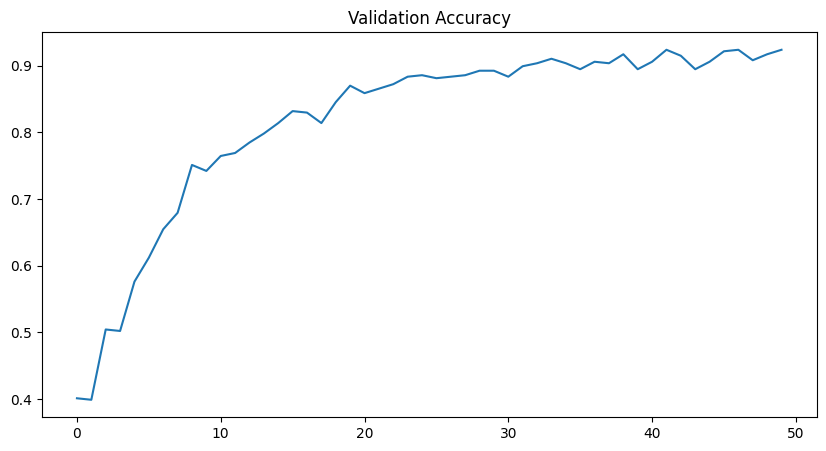

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig(PLOT_DIR / "loss_curve.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.savefig(PLOT_DIR / "accuracy_curve.png")
plt.show()

In [15]:
checkpoint = torch.load(
    MODEL_DIR / "best_model.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_to_idx.keys()
))

Accuracy: 0.9418
                       precision    recall  f1-score   support

       Astrocytoma T2       0.97      0.88      0.93        42
        Ependymoma T2       0.93      1.00      0.96        53
            Glioma T2       0.95      0.95      0.95        61
Hemangiopericytoma T2       1.00      0.88      0.94        17
        Meningioma T2       0.89      0.94      0.92        69
       Neurocytoma T2       0.96      0.96      0.96        26
            Normal T2       0.92      0.98      0.95        57
 Oligodendroglioma T2       1.00      0.80      0.89        20
             Other T2       0.94      0.91      0.93        55
        Schwannoma T2       0.98      0.98      0.98        47

             accuracy                           0.94       447
            macro avg       0.95      0.93      0.94       447
         weighted avg       0.94      0.94      0.94       447



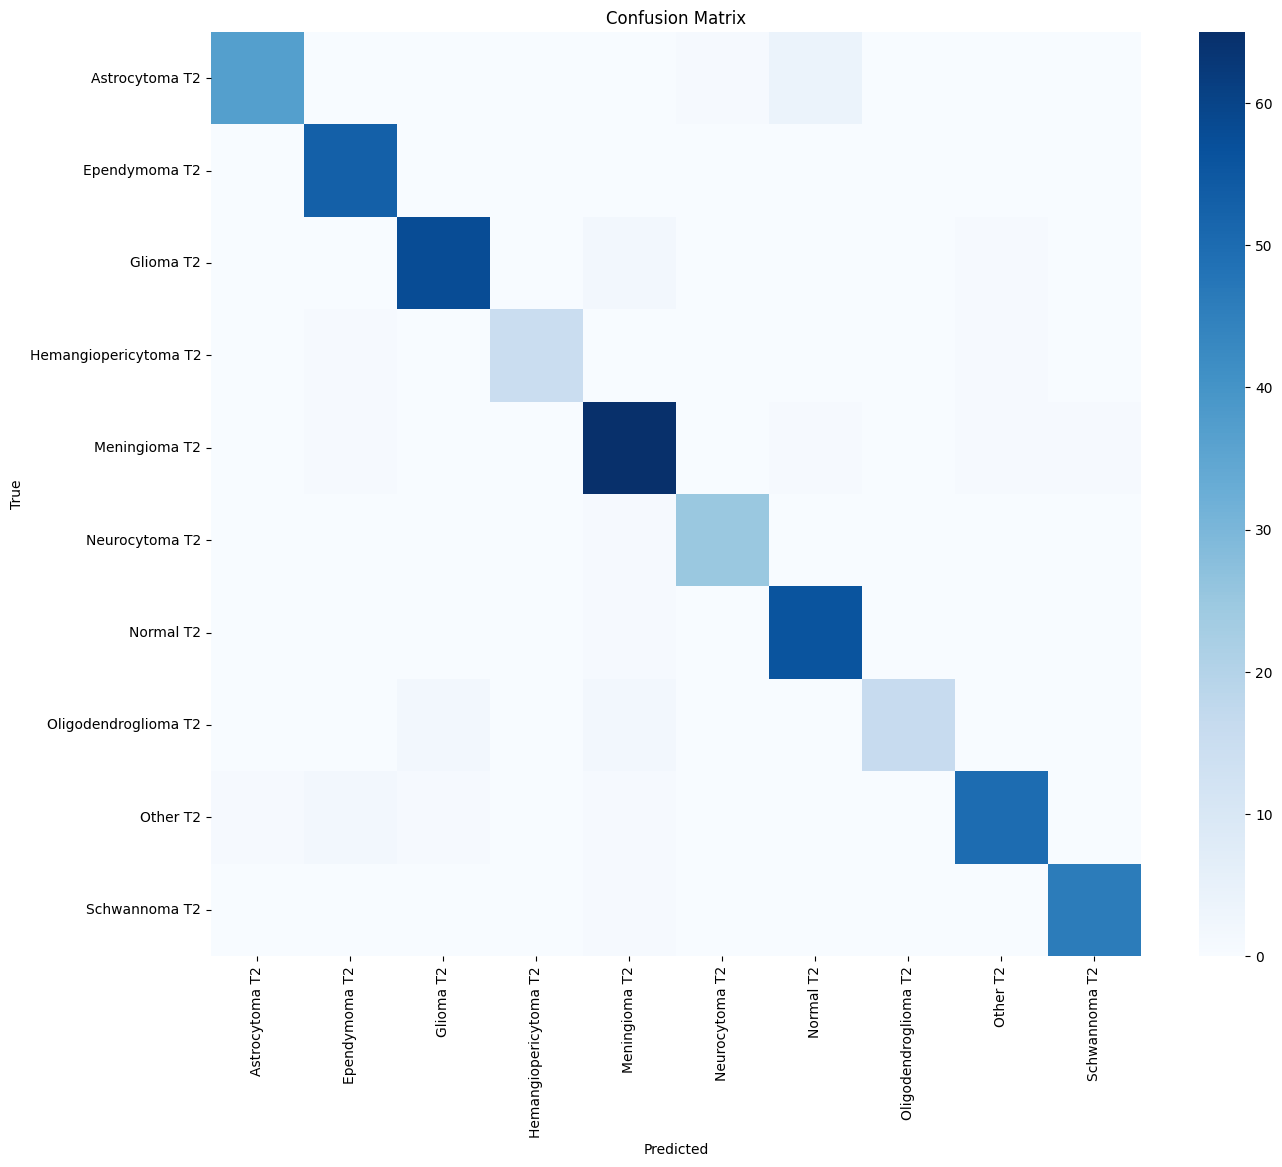

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_to_idx.keys(),
    yticklabels=class_to_idx.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(CONFUSION_DIR / "confusion_matrix.png")

plt.show()

Classe prevista: Oligodendroglioma T2
Confiança: 97.84%


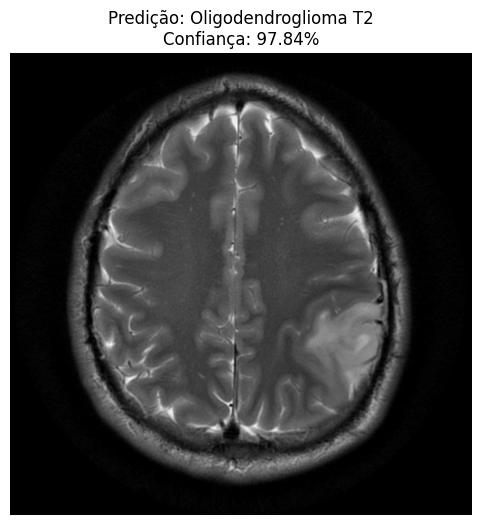

In [18]:
image_path = "/home/nathan/Desktop/batata.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Imagem não encontrada: {image_path}")

# Transformações
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Carrega imagem
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Erro ao carregar imagem")

# Mantém original para visualização
original_image = image.copy()

# PIL
image_pil = Image.fromarray(image)

# Tensor
image_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

# Inferência
model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    predicted_class = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][predicted_class].item()

predicted_label = idx_to_class[predicted_class]

print(f"Classe prevista: {predicted_label}")
print(f"Confiança: {confidence * 100:.2f}%")

# Exibe imagem
plt.figure(figsize=(6, 6))

plt.imshow(original_image, cmap="gray")

plt.title(
    f"Predição: {predicted_label}\n"
    f"Confiança: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

In [19]:
# Caminhos
final_model_path = MODEL_DIR / "final_model_weights.pth"

checkpoint_path = MODEL_DIR / "complete_checkpoint.pth"

# Salva pesos
torch.save(
    model.state_dict(),
    final_model_path
)

# Salva checkpoint completo
checkpoint = {

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    "class_to_idx": class_to_idx,

    "idx_to_class": idx_to_class,

    "best_accuracy": best_accuracy,

    "epochs": EPOCHS,

    "learning_rate": LEARNING_RATE
}

torch.save(
    checkpoint,
    checkpoint_path
)

print("Modelo salvo com sucesso")

print(f"Pesos: {final_model_path}")

print(f"Checkpoint: {checkpoint_path}")

Modelo salvo com sucesso
Pesos: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/final_model_weights.pth
Checkpoint: /home/nathan/Documents/Projects/IA/Projeto_IA_Tumor/outputs/models/complete_checkpoint.pth


In [20]:
# Recria arquitetura
loaded_model = BrainTumorCNN(
    num_classes=len(class_to_idx)
)

# Carrega checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

# Carrega pesos
loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Move para dispositivo
loaded_model.to(DEVICE)

loaded_model.eval()

print("Modelo carregado com sucesso")

print(
    "Melhor accuracy:",
    checkpoint["best_accuracy"]
)

Modelo carregado com sucesso
Melhor accuracy: 0.9237668161434978


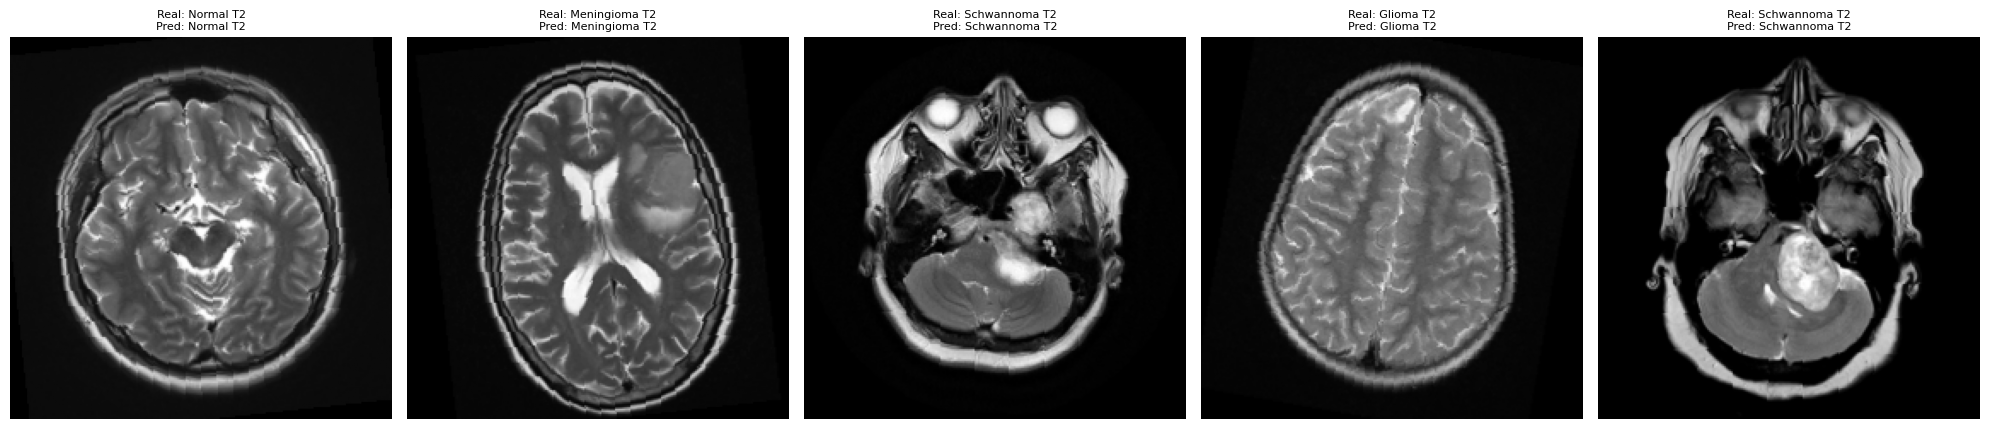

In [21]:
num_images = 5

model.eval()

fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(20, 5)
)

with torch.no_grad():

    for i in range(num_images):

        image, label = test_dataset[i]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        output = model(input_tensor)

        pred = torch.argmax(
            output,
            dim=1
        ).item()

        image_np = image.squeeze().cpu().numpy()

        axes[i].imshow(
            image_np,
            cmap="gray"
        )

        axes[i].set_title(
            f"Real: {idx_to_class[label]}\n"
            f"Pred: {idx_to_class[pred]}",
            fontsize=8
        )

        axes[i].axis("off")

plt.tight_layout()

plt.show()

In [22]:
print("=" * 50)
print("RESUMO FINAL DO TREINAMENTO")
print("=" * 50)

print(f"Número de classes: {len(classes)}")

print(f"Total de imagens: {len(all_samples)}")

print(f"Imagens treino: {len(train_samples)}")

print(f"Imagens validação: {len(val_samples)}")

print(f"Imagens teste: {len(test_samples)}")

print(
    f"\nMelhor accuracy: "
    f"{best_accuracy:.4f}"
)

print(
    f"Learning Rate: "
    f"{LEARNING_RATE}"
)

print(
    f"Batch Size: "
    f"{BATCH_SIZE}"
)

print(
    f"Épocas: "
    f"{EPOCHS}"
)

print(
    f"Dispositivo: "
    f"{DEVICE}"
)

print("=" * 50)

RESUMO FINAL DO TREINAMENTO
Número de classes: 10
Total de imagens: 2976
Imagens treino: 2083
Imagens validação: 446
Imagens teste: 447

Melhor accuracy: 0.9238
Learning Rate: 0.0001
Batch Size: 16
Épocas: 50
Dispositivo: cuda


In [23]:
onnx_path = MODEL_DIR / "brain_tumor_model.onnx"

sample_input = torch.randn(
    1,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(DEVICE)

torch.onnx.export(
    model,

    sample_input,

    onnx_path,

    export_params=True,

    opset_version=11,

    do_constant_folding=True,

    input_names=['input'],

    output_names=['output']
)

print(
    f"Modelo ONNX salvo em: "
    f"{onnx_path}"
)

ModuleNotFoundError: No module named 'onnxscript'

In [24]:
test_folder = DATASET_DIR / list(class_to_idx.keys())[0]

model.eval()

results = []

with torch.no_grad():

    for image_path in test_folder.glob("*.jpg"):

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        image_pil = Image.fromarray(image)

        tensor = transform(image_pil)\
            .unsqueeze(0)\
            .to(DEVICE)

        output = model(tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs[0][pred].item()

        results.append({
            "image": image_path.name,
            "prediction": idx_to_class[pred],
            "confidence": confidence
        })

df_results = pd.DataFrame(results)

print(df_results.head())

                                               image      prediction  \
0  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
1  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
2  T2 - Anaplastic astrocytoma (pineal region) 00...  Astrocytoma T2   
3  T2 - Anaplastic astrocytoma (pineal region) 00...   Meningioma T2   
4            T2 - Anaplastic astrocytoma NOS 004.jpg  Astrocytoma T2   

   confidence  
0    0.436244  
1    0.960279  
2    0.955852  
3    0.487258  
4    0.999922  
